In [11]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

class StockPredictionModel:
    def __init__(self, ticker, period='5y'):
        self.ticker = ticker
        self.period = period
        self.model = RandomForestRegressor(n_estimators=100, random_state=42)
        self.features = ['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_7', 'SMA_21']
        self.df = None

    def fetch_and_preprocess(self):
        df = yf.download(self.ticker, period=self.period, interval='1d', auto_adjust=True)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = [col[0] for col in df.columns]
        df['SMA_7'] = df['Close'].rolling(window=7).mean()
        df['SMA_21'] = df['Close'].rolling(window=21).mean()
        df['Target'] = df['Close'].shift(-1)
        self.df = df.dropna()
        return self.df

    def train_and_evaluate(self):
        X = self.df[self.features]
        y = self.df['Target']
        split = int(len(X) * 0.8)
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        self.model.fit(X_train, y_train)
        y_pred = self.model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Results for {self.ticker}:")
        print(f"MSE: {mse:.4f}")
        print(f"R2 Score: {r2:.4f}")

        return X_test, y_test, y_pred

model_instance = StockPredictionModel('AAPL')
model_instance.fetch_and_preprocess()
xtest, ytest, ypred = model_instance.train_and_evaluate()

[*********************100%***********************]  1 of 1 completed


Results for AAPL:
MSE: 128.7341
R2 Score: 0.8503


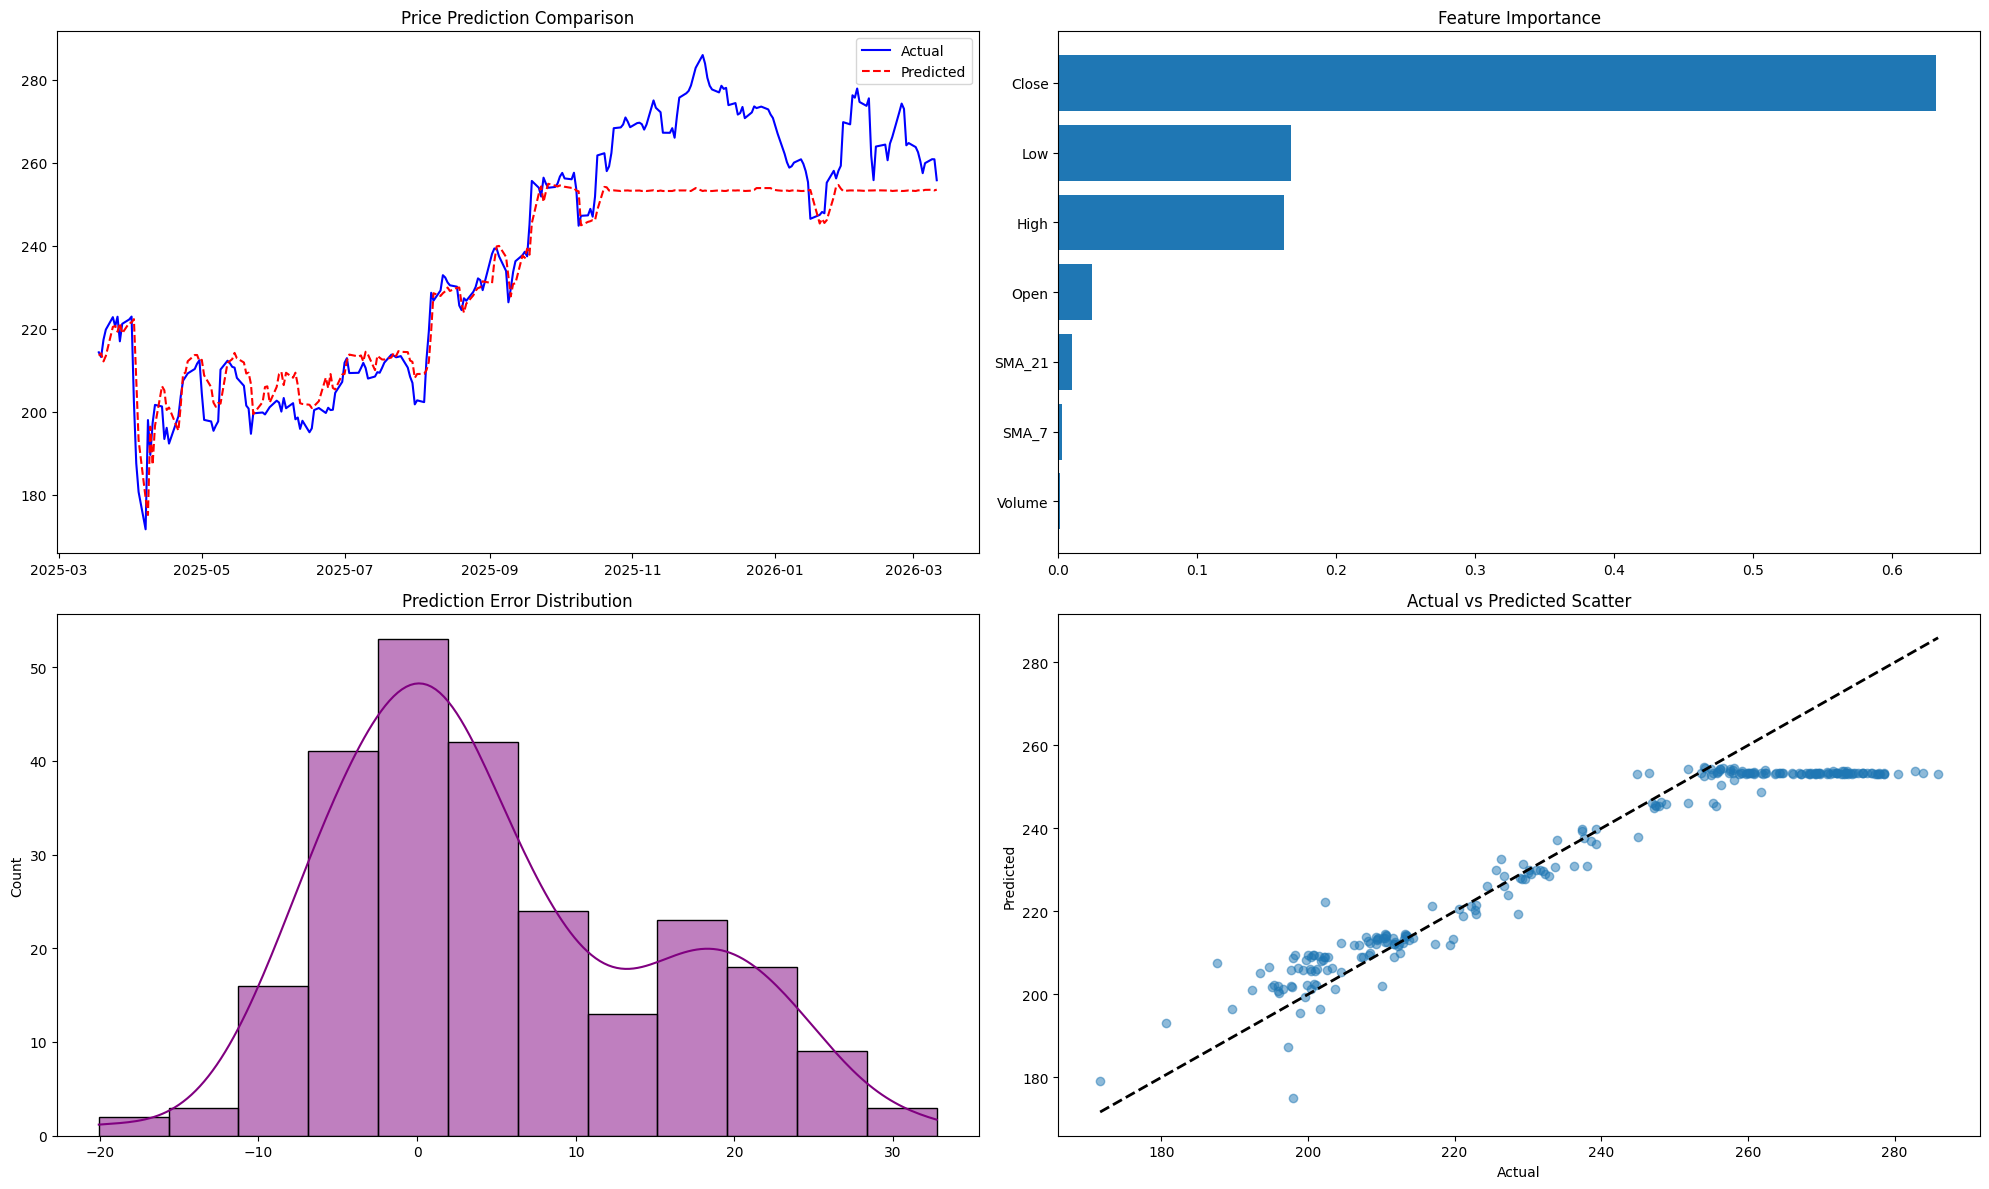

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

axes[0, 0].plot(ytest.index, ytest.values, label='Actual', color='blue')
axes[0, 0].plot(ytest.index, ypred, label='Predicted', color='red', linestyle='--')
axes[0, 0].set_title('Price Prediction Comparison')
axes[0, 0].legend()

importances = model_instance.model.feature_importances_
indices = np.argsort(importances)
axes[0, 1].barh(range(len(indices)), importances[indices], align='center')
axes[0, 1].set_yticks(range(len(indices)), [model_instance.features[i] for i in indices])
axes[0, 1].set_title('Feature Importance')

errors = ytest.values - ypred
sns.histplot(errors, kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Prediction Error Distribution')

axes[1, 1].scatter(ytest.values, ypred, alpha=0.5)
axes[1, 1].plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], 'k--', lw=2)
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')
axes[1, 1].set_title('Actual vs Predicted Scatter')

plt.tight_layout()
plt.show()

In [13]:
import pickle
from google.colab import files

with open('aapl_stock_model.pkl', 'wb') as f:
    pickle.dump(model_instance.model, f)

files.download('aapl_stock_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>